# Multi-Session PCA Analysis - Class Usage



In [2]:
# Imports
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

from pprint import pprint

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

# Import the class
import importlib
import session_class
importlib.reload(session_class)
from session_class import Session

# Also reload multi_session_pca if needed
import multi_session_pca
importlib.reload(multi_session_pca)
from multi_session_pca import MultiSessionPCA

print("✓ Imports loaded successfully!")

✓ Imports loaded successfully!


## Example 1: Basic Usage with Default Configuration

In [22]:
# Initialize with default configuration
analyzer = MultiSessionPCA({
    'epok': [-100, 200],
    'bin_size': 1,
    'smooth_ker_size': 25,
    'alignment_point': 'go_cue',
    'ssd_number': 2,
    'normalize': False,
    'delta': False,
    'subtract_average_PSTH': False
})

# Check default config
print("Default Configuration:")
pprint(analyzer.config)

Default Configuration:
{'alignment_point': 'go_cue',
 'bin_size': 1,
 'delta': False,
 'epok': [-100, 200],
 'excluded_sessions': ['fi210628', 'fi210629', 'fi210704'],
 'figsize_2d_grid': (7, 19),
 'figsize_3d': (12, 10),
 'figsize_time': (10, 3),
 'min_cells_per_session': 10,
 'min_trials_per_condition': 5,
 'monkey': 'fiona',
 'n_pca_components': 5,
 'n_workers': 6,
 'normalize': False,
 'required_directions': [0, 180],
 'required_trial_types': ['GO', 'STOP', 'CONT'],
 'smooth_ker_size': 25,
 'ssd_number': 2,
 'subtract_average_PSTH': False}


In [23]:
# Load data
base_path = Path.cwd().parent / 'data' / 'unified_cell_trial_data'
pickle_file = base_path / 'msn_fiona_cell_trial_data.pkl'

analyzer.load_data(pickle_file)

Loading data from: /Users/barak/Projects/population_analysis/data/unified_cell_trial_data/msn_fiona_cell_trial_data.pkl
✓ Database loaded: 770,705 cell-trial combinations
  Total sessions: 60
  Total unique cells: 1414


In [24]:
# Validate sessions
analyzer.validate_all_sessions(verbose=True)

✓ Session statistics computed for 60 sessions
  Excluded sessions: 1
  Candidate sessions: 59
Validating sessions...
--------------------------------------------------------------------------------
Cell 2134 removed from session fi211110a.
Dropped 1 cell with incomplete trial type or directional data.
✓ fi211110a: Valid (84 cells)
✓ fi211026a: Valid (76 cells)
✓ fi211102a: Valid (71 cells)
✓ fi211111a: Valid (64 cells)
✓ fi211025a: Valid (63 cells)
✓ fi211104a: Valid (59 cells)
✓ fi211109a: Valid (59 cells)
✓ fi211122a: Valid (58 cells)
✓ fi211115a: Valid (53 cells)
✓ fi211118a: Valid (52 cells)
✓ fi211020a: Valid (49 cells)
✓ fi211108a: Valid (42 cells)
✓ fi211018a: Valid (40 cells)
✓ fi211123a: Valid (36 cells)
✓ fi211019a: Valid (34 cells)
✓ fi211125a: Valid (34 cells)
✓ fi211014a: Valid (32 cells)
✓ fi211017a: Valid (32 cells)
✓ fi211103a: Valid (29 cells)
✓ fi211021a: Valid (27 cells)
✓ fi211124a: Valid (26 cells)
✓ fi210907a: Valid (25 cells)
✓ fi210909a: Valid (23 cells)
✓ fi211

In [25]:
# Extract PSTH matrices (parallel processing)
sessions_PSTHs = analyzer.extract_all_sessions_parallel(pickle_path=pickle_file)

Extracting PSTHs from 40 sessions using 6 workers...
  Using pre-loaded data (efficient mode)
  Subtract average: False
--------------------------------------------------------------------------------
Cell 2134 removed from session fi211110a.
Dropped 1 cell with incomplete trial type or directional data.


Processing:   2%|▎         | 1/40 [00:01<01:16,  1.95s/it]

[1/40] ✓ fi211102a: 71 cells


Processing:   5%|▌         | 2/40 [00:02<00:37,  1.01it/s]

[2/40] ✓ fi211026a: 75 cells (dropped 1 with no STOP ssd=2)


...

Processing:  95%|█████████▌| 38/40 [00:10<00:00, 11.18it/s]

[38/40] ✓ fi210901a: 12 cells
[39/40] ✓ fi210815a: 11 cells


Processing: 100%|██████████| 40/40 [00:10<00:00,  3.77it/s]

[40/40] ✓ fi210809a: 10 cells


--------------------------------------------------------------------------------
✓ Extraction complete: 40/40 successful
  ⚠ SSD filtering: 4/1322 cells dropped (0.3%)
  Cells retained: 1318


In [26]:
# Prepare data for PCA
analyzer.concatenate_sessions()
# analyzer.subtract_average_PSTH()

Concatenating PSTH matrices across sessions...
✓ Concatenation complete:
  GO Left: (1318, 300)
  GO Right: (1318, 300)
  STOP Left: (1318, 300)
  STOP Right: (1318, 300)


In [27]:
analyzer.fit_pca(pca_type='PCA', subtract_average=True)
analyzer.project_all_conditions()

✓ PCA matrix prepared: (1318, 600)
  (n_cells=1318, n_features=600)
Fitting PCA with 5 components...
✓ PCA fitted
  PC1: 55.72% variance
  PC2: 20.13% variance
  PC3: 9.84% variance
  PC4: 4.18% variance
  PC5: 2.83% variance
  Total: 92.70%
Projecting all conditions onto PC space...
✓ Projections complete:
  GO Left: (5, 300)
  GO Right: (5, 300)
  STOP Left: (5, 300)
  STOP Right: (5, 300)


In [28]:
# analyzer.normalize_pcs()

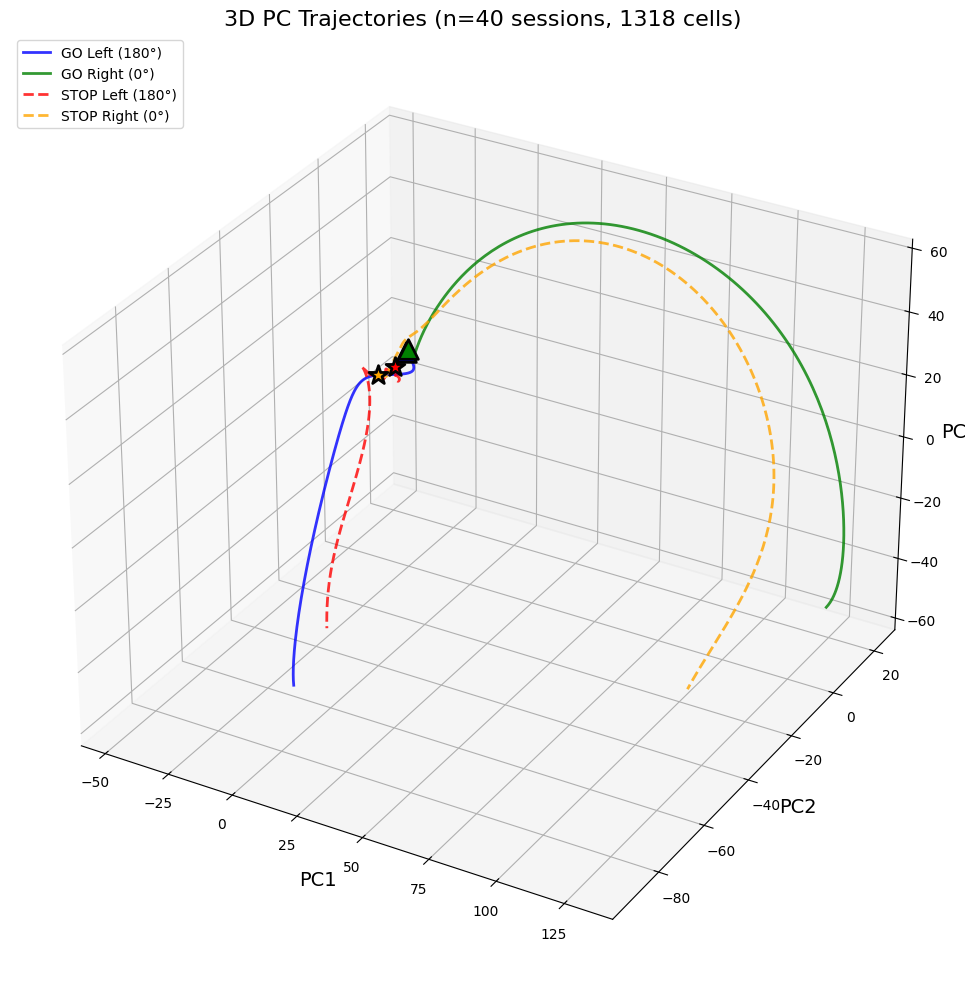

(<Figure size 1200x1000 with 1 Axes>,
 <Axes3D: title={'center': '3D PC Trajectories (n=40 sessions, 1318 cells)'}, xlabel='PC1', ylabel='PC2', zlabel='PC3'>)

In [29]:
# Visualize results
analyzer.plot_3d_trajectory()

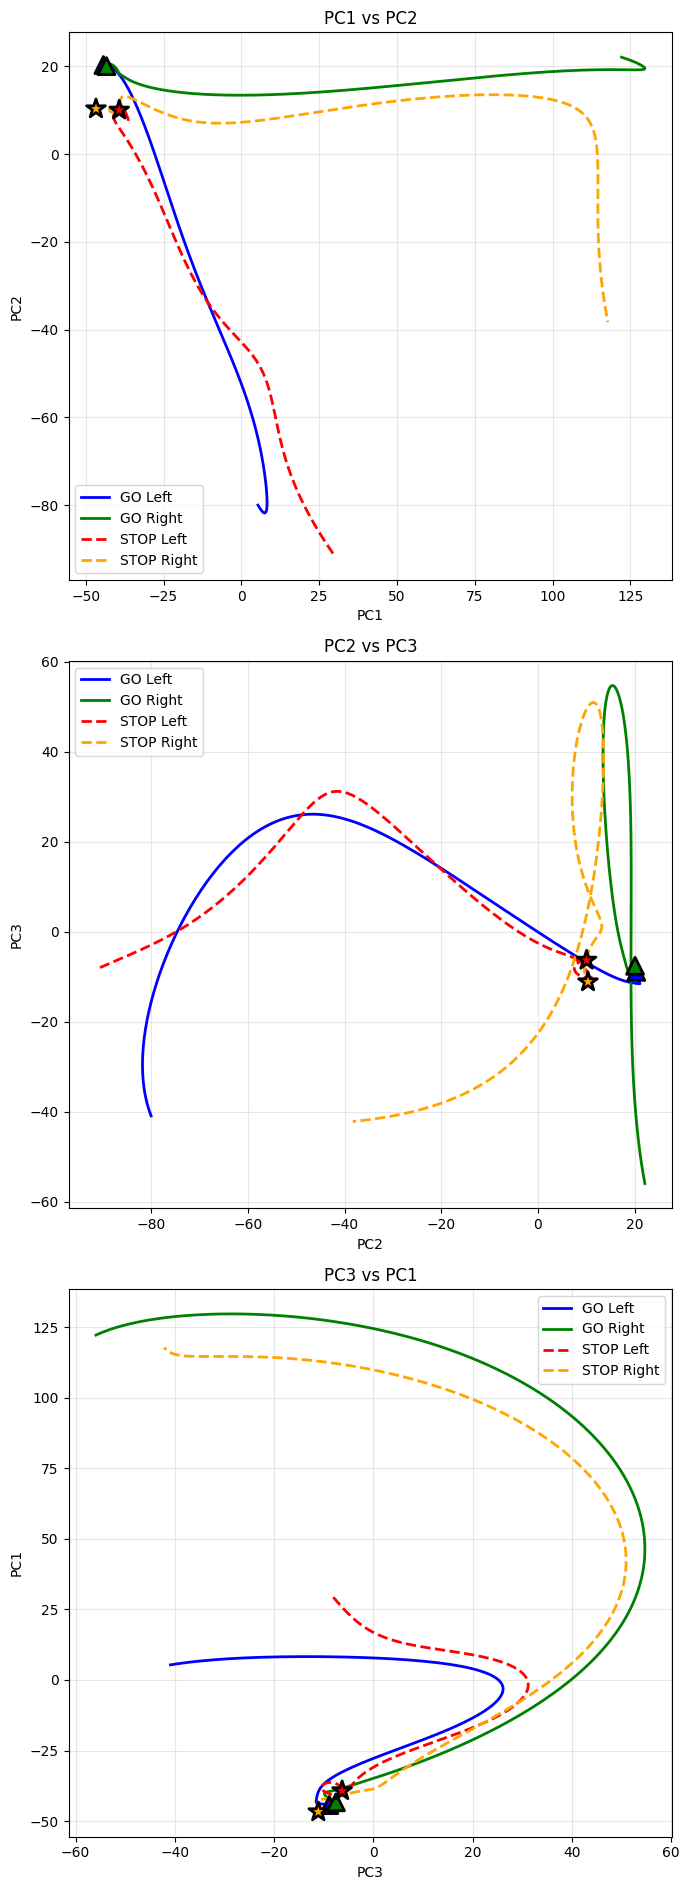

(<Figure size 700x1900 with 3 Axes>,
 array([<Axes: title={'center': 'PC1 vs PC2'}, xlabel='PC1', ylabel='PC2'>,
        <Axes: title={'center': 'PC2 vs PC3'}, xlabel='PC2', ylabel='PC3'>,
        <Axes: title={'center': 'PC3 vs PC1'}, xlabel='PC3', ylabel='PC1'>],
       dtype=object))

In [30]:
# 2D projections grid
analyzer.plot_2d_grid()

In [31]:
pc1, pc2, pc3 = [np.concat((analyzer.go_left_PCs[i], analyzer.go_right_PCs[i])) for i in range(3)]
correlations = {}
for i, (pc_i, name_i) in enumerate([(pc1, 'PC1'), (pc2, 'PC2'), (pc3, 'PC3')]):
    for j, (pc_j, name_j) in enumerate([(pc1, 'PC1'), (pc2, 'PC2'), (pc3, 'PC3')]):
        if i < j:
            corr = np.corrcoef(pc_i, pc_j)[0, 1]
            correlations[f'{name_i}-{name_j}'] = corr
            print(f"Correlation between {name_i} and {name_j}: {corr:.4f}")

Correlation between PC1 and PC2: 0.0000
Correlation between PC1 and PC3: 0.0000
Correlation between PC2 and PC3: -0.0000


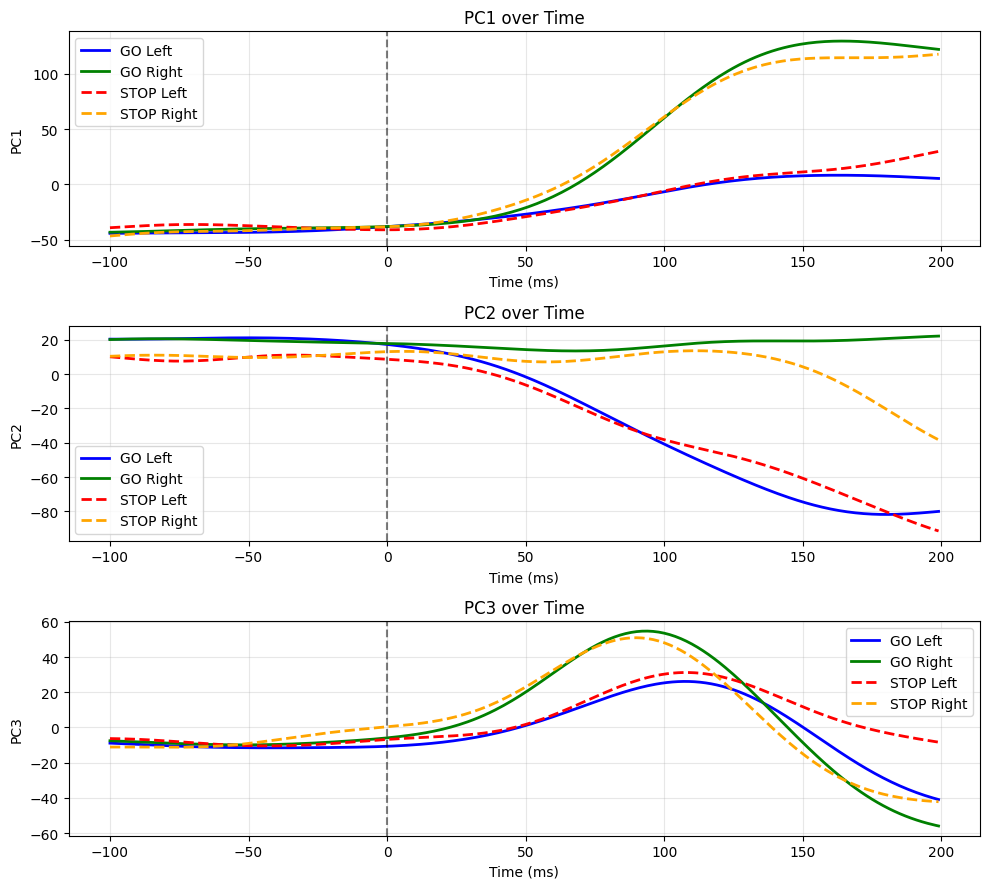

(<Figure size 1000x900 with 3 Axes>,
 array([<Axes: title={'center': 'PC1 over Time'}, xlabel='Time (ms)', ylabel='PC1'>,
        <Axes: title={'center': 'PC2 over Time'}, xlabel='Time (ms)', ylabel='PC2'>,
        <Axes: title={'center': 'PC3 over Time'}, xlabel='Time (ms)', ylabel='PC3'>],
       dtype=object))

In [32]:
# PC time series
analyzer.plot_pc_timeseries(pcs_to_plot=[0, 1, 2])

In [33]:
a = analyzer.cell_df['type'] == 'STOP'
b = analyzer.cell_df['trial_failed'] == False
c = analyzer.cell_df['ssd_number'] == analyzer.config['ssd_number']

analyzer.cell_df[a & b & c]['ssd_len'].apply(['mean', 'std'])

mean    109.520735
std       7.340527
Name: ssd_len, dtype: float64

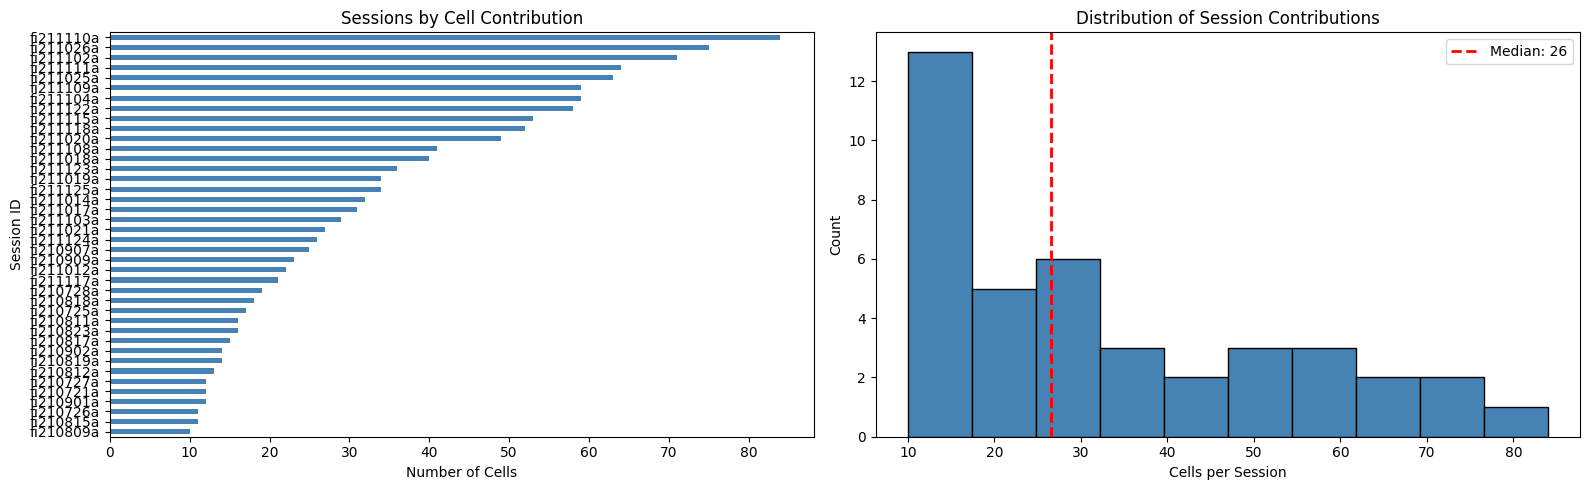

(<Figure size 1600x500 with 2 Axes>,
 array([<Axes: title={'center': 'Sessions by Cell Contribution'}, xlabel='Number of Cells', ylabel='Session ID'>,
        <Axes: title={'center': 'Distribution of Session Contributions'}, xlabel='Cells per Session', ylabel='Count'>],
       dtype=object))

In [34]:
# Session contributions
analyzer.plot_session_contributions()